In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('/kaggle/input/datasets/sanjanchaudhari/spotify-dataset/cleaned_dataset.csv')

print("Shape of dataset:", df.shape)
print("\nColumn names:\n", df.columns)
print("\nFirst 5 rows:\n", df.head())

print("\nDataset Info:\n")
df.info()


print(df.describe(include='all'))


Shape of dataset: (20594, 24)

Column names:
 Index(['Artist', 'Track', 'Album', 'Album_type', 'Danceability', 'Energy',
       'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness',
       'Liveness', 'Valence', 'Tempo', 'Duration_min', 'Title', 'Channel',
       'Views', 'Likes', 'Comments', 'Licensed', 'official_video', 'Stream',
       'EnergyLiveness', 'most_playedon'],
      dtype='object')

First 5 rows:
      Artist                                          Track  \
0  Gorillaz                                 Feel Good Inc.   
1  Gorillaz                                Rhinestone Eyes   
2  Gorillaz  New Gold (feat. Tame Impala and Bootie Brown)   
3  Gorillaz                             On Melancholy Hill   
4  Gorillaz                                 Clint Eastwood   

                                           Album Album_type  Danceability  \
0                                     Demon Days      album         0.818   
1                                  Plastic Beach 

In [2]:
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 Artist              0
Track               0
Album               0
Album_type          0
Danceability        0
Energy              0
Loudness            0
Speechiness         0
Acousticness        0
Instrumentalness    0
Liveness            0
Valence             0
Tempo               0
Duration_min        0
Title               0
Channel             0
Views               0
Likes               0
Comments            0
Licensed            0
official_video      0
Stream              0
EnergyLiveness      2
most_playedon       0
dtype: int64


In [3]:

print("Missing values after fix:\n", df.isnull().sum())


Missing values after fix:
 Artist              0
Track               0
Album               0
Album_type          0
Danceability        0
Energy              0
Loudness            0
Speechiness         0
Acousticness        0
Instrumentalness    0
Liveness            0
Valence             0
Tempo               0
Duration_min        0
Title               0
Channel             0
Views               0
Likes               0
Comments            0
Licensed            0
official_video      0
Stream              0
EnergyLiveness      2
most_playedon       0
dtype: int64


In [4]:
df.fillna({'EnergyLiveness': df['EnergyLiveness'].median()}, inplace=True)


In [5]:
df.head()

,Artist,Track,Album,Album_type,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,...,Title,Channel,Views,Likes,Comments,Licensed,official_video,Stream,EnergyLiveness,most_playedon
0,Gorillaz,Feel Good Inc.,Demon Days,album,0.818,0.705,-6.679,0.1770,0.008360,0.002330,...,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,True,True,1.040235e+09,1.150082,Spotify
1,Gorillaz,Rhinestone Eyes,Plastic Beach,album,0.676,0.703,-5.815,0.0302,0.086900,0.000687,...,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,True,True,3.100837e+08,15.183585,Spotify
2,Gorillaz,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,0.695,0.923,-3.930,0.0522,0.042500,0.046900,...,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055.0,282142.0,7399.0,True,True,6.306347e+07,7.956897,Spotify
3,Gorillaz,On Melancholy Hill,Plastic Beach,album,0.689,0.739,-5.810,0.0260,0.000015,0.509000,...,Gorillaz - On Melancholy Hill (Official Video),Gorillaz,211754952.0,1788577.0,55229.0,True,True,4.346636e+08,11.546875,Spotify
4,Gorillaz,Clint Eastwood,Gorillaz,album,0.663,0.694,-8.627,0.1710,0.025300,0.000000,...,Gorillaz - Clint Eastwood (Official Video),Gorillaz,618480958.0,6197318.0,155930.0,True,True,6.172597e+08,9.942693,Youtube


In [6]:
categorical_cols = ['Album_type','Licensed','official_video','most_playedon']
for col in categorical_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())



Unique values in Album_type:
['album' 'single' 'compilation']

Unique values in Licensed:
['True' 'False' '0']

Unique values in official_video:
['True' 'False' '0']

Unique values in most_playedon:
['Spotify' 'Youtube']


In [7]:

df['Licensed'] = df['Licensed'].replace({'0': 'False'})
df['official_video'] = df['official_video'].replace({'0': 'False'})

# Verify again
print("Unique values in Licensed:", df['Licensed'].unique())
print("Unique values in official_video:", df['official_video'].unique())


Unique values in Licensed: ['True' 'False']
Unique values in official_video: ['True' 'False']


In [8]:
df.to_csv('/kaggle/working/spotify_cleaned.csv', index=False)

print("✅ Cleaned dataset saved as spotify_cleaned.csv in /kaggle/working/")


✅ Cleaned dataset saved as spotify_cleaned.csv in /kaggle/working/


In [9]:
print(df.columns)


Index(['Artist', 'Track', 'Album', 'Album_type', 'Danceability', 'Energy',
       'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness',
       'Liveness', 'Valence', 'Tempo', 'Duration_min', 'Title', 'Channel',
       'Views', 'Likes', 'Comments', 'Licensed', 'official_video', 'Stream',
       'EnergyLiveness', 'most_playedon'],
      dtype='object')


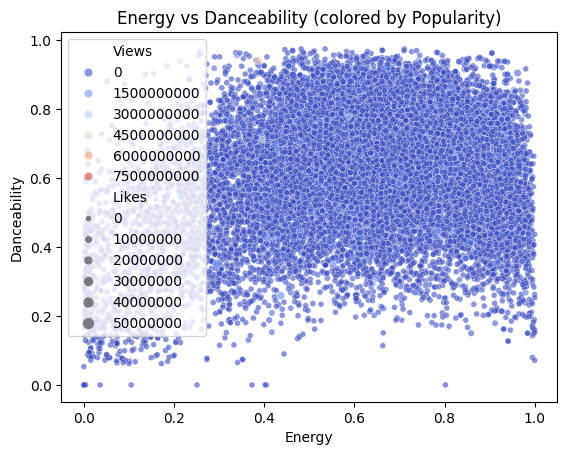

In [10]:
import seaborn as sns 
import matplotlib.pyplot as plt
sns.scatterplot(x='Energy', y='Danceability', hue='Views', size='Likes',
                data=df, alpha=0.6, palette='coolwarm')
plt.title("Energy vs Danceability (colored by Popularity)")
plt.show()